In [1]:
# From past Labs

from skimage.color import rgb2hsv, rgb2gray
from skimage.morphology import closing, opening, disk, remove_small_holes, remove_small_objects, binary_dilation, erosion
from skimage.transform import rotate, resize, AffineTransform, warp
from sklearn.metrics.pairwise import euclidean_distances
from skimage.measure import regionprops
import matplotlib.image as mpimg


import os
import copy
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from src.Project_utils import *
from src.arno_utils import *

from sklearn.metrics import accuracy_score, f1_score
import cv2

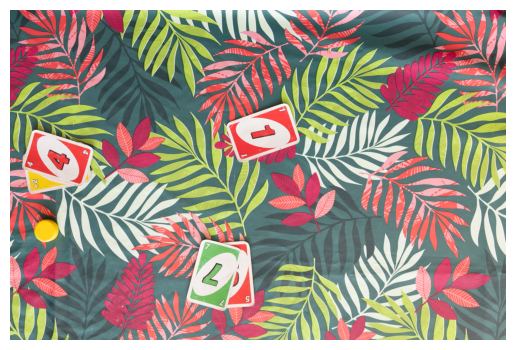

In [2]:
# Shows the imaga treated 
#img = mpimg.imread("data/iapr-26-uno-vision-challenge/train_images/L1000915.jpg") #image with leaves
#img = mpimg.imread("data/iapr-26-uno-vision-challenge/train_images/L1000775.jpg") #fond blanc
img = mpimg.imread("data/iapr-26-uno-vision-challenge/train_images/L1000966.jpg") #overlap
plt.imshow(img)
plt.axis("off")
plt.show()

In [3]:
#TO REMOVE - doesnt work 
'''
contours = find_contour(np.array([img[:, :, 0]]))
print(contours[0].shape)
print(img.shape)
display_img_with_contour(img, "path", "Image with contour", cnt=contours[0])
'''

'\ncontours = find_contour(np.array([img[:, :, 0]]))\nprint(contours[0].shape)\nprint(img.shape)\ndisplay_img_with_contour(img, "path", "Image with contour", cnt=contours[0])\n'

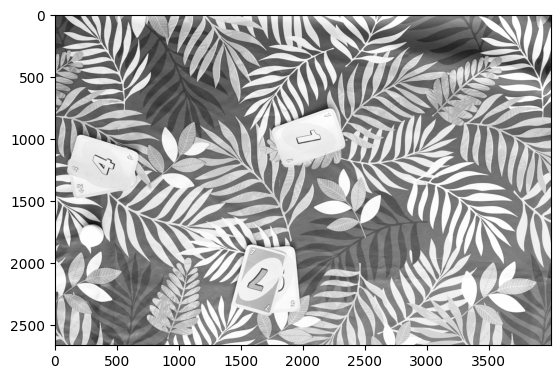

In [4]:
#get hsv value of the image
img_hsv = rgb2hsv(img)
plt.imshow(img_hsv[:,:,2], cmap='gray')

In [5]:
#to improve, here i should be able to tweak paremers pf hsv trehsolds - here i have to restart kernel each time...
color_masks = {
    'red': apply_hsv_threshold_v2(img, mode='red'),
    'blue': apply_hsv_threshold_v2(img, mode='blue'),
    'yellow': apply_hsv_threshold_v2(img, mode='yellow'),
    'green': apply_hsv_threshold_v2(img, mode='green'),
    'black': apply_hsv_threshold_v2(img, mode='black'),
}

(2662, 4000)


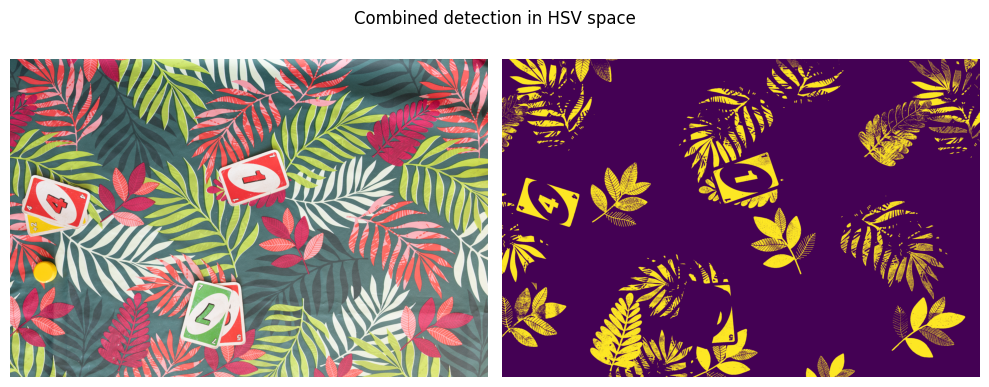

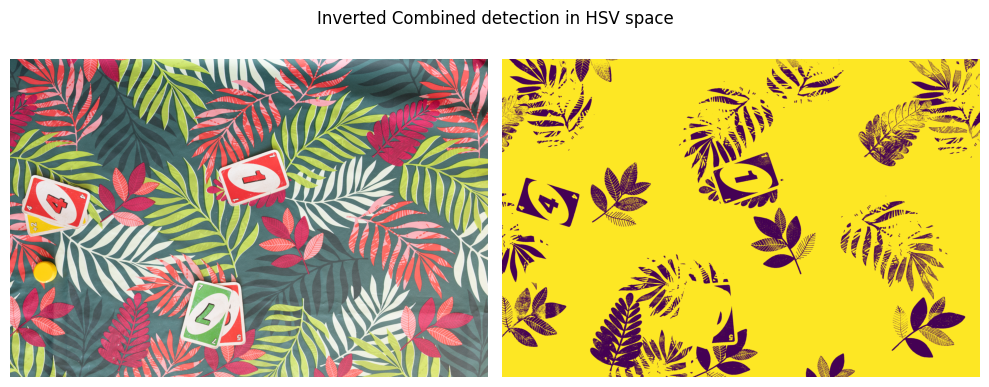

In [6]:
#plotting only red FOR EXAMPLE THEN ONE FCT FOR ALL COLORS 
final_mask = color_masks['red']
print(final_mask.shape)


#to try after thresholds tuning
#final_mask = apply_closing(final_mask, disk_size=2)
#final_mask = apply_opening(final_mask, disk_size=2)
#final_mask = apply_erosion(final_mask, disk_size=2)


plot_thresholded_image(
            img=img,
            func=lambda img: final_mask,
            title=f"Combined detection in HSV space"
        )

inverted_final_mask = np.invert(final_mask)
plot_thresholded_image(
            img=img,
            func=lambda img: inverted_final_mask,
            title=f"Inverted Combined detection in HSV space"
        )

Number of large contours: 126


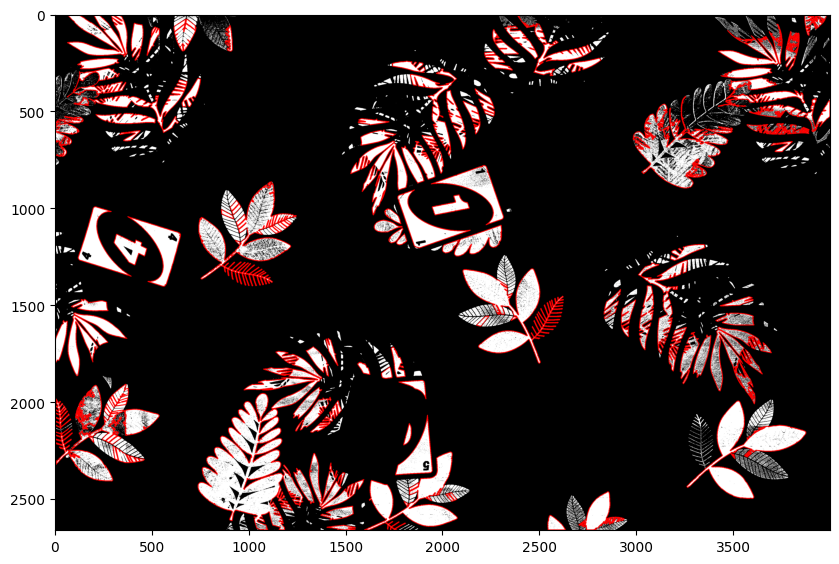

In [7]:
contours = find_contour_with_threshold(final_mask, arbitrary_minimal_area=1000, plot=True)

Aspect ratios of the top 10 contours: [26.722961688471756, 24.220063093846193, 24.121718132207796, 23.906758798841548, 23.43720771247079, 22.090744015540018, 21.369338754986508, 20.862035414180987, 20.621293120259867, 17.289615409261277]
Aspect Ratios of the top contours: [26.722961688471756, 24.220063093846193, 24.121718132207796, 23.906758798841548, 23.43720771247079, 22.090744015540018, 21.369338754986508, 20.862035414180987, 20.621293120259867, 17.289615409261277]
Areas of top aspect ratio contours: [23725.0, 28689.0, 29474.0, 29774.5, 28470.5, 13220.0, 176011.5, 81162.5, 19444.5, 64368.0]


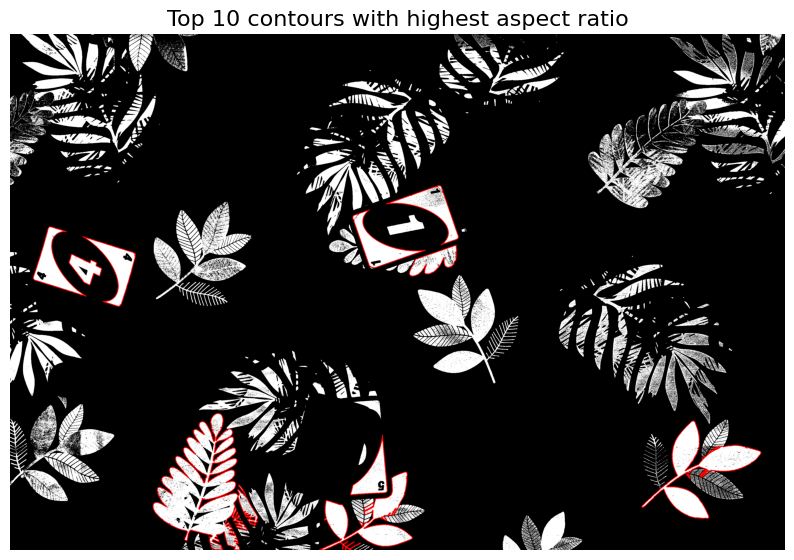

here


In [8]:
#issue with this function. need to know the number of contours
#a fix could be an arbitratry threshold of area and aspect ratio

contours_high_ar = relevant_contours_finder(final_mask, contours, contours_to_consider=10, infos_and_plot=True)

(281, 2)
10
(10, 25, 2)


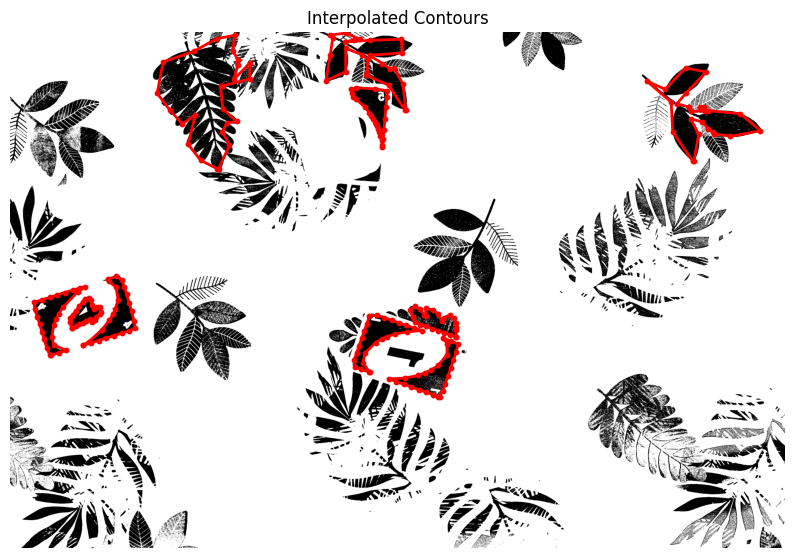

In [9]:
#interpolation of contours to reduce computation and have same nbr

new_contours = [c.reshape(-1, 2) for c in contours_high_ar]
print(new_contours[0].shape)
print(len(new_contours))


contours_inter = linear_interpolation(new_contours, n_samples=25) #now a list of all contoues with N points each
print(contours_inter.shape)

# Plot
plot_interpolated_contours(
    inverted_final_mask,
    contours_inter
)


In [10]:
def compute_distance_matrix(contours):
    N = contours.shape[0]
    print(f"Number of contours: {N}")

    distances = np.zeros((N, N))
    for cnt in range(N):
        for cnt2 in range(N):
            if cnt != cnt2:
                distances[cnt, cnt2] = np.mean(np.linalg.norm(contours[cnt] - contours[cnt2], axis=1))
            else :
                distances[cnt, cnt2] = np.inf        
    return distances
    
distances = compute_distance_matrix(contours_inter)
#formatted print of the distance matrix
print("Distance Matrix:")
for i in range(distances.shape[0]):
    print(" ".join(f"{distances[i, j]:.2f}" for j in range(distances.shape[1])))



Number of contours: 10
Distance Matrix:
inf 1953.88 1168.02 1364.94 1698.97 1809.97 842.16 1680.96 1109.91 304.78
1953.88 inf 1673.37 1971.95 306.79 187.87 1405.58 3485.90 1969.32 2094.29
1168.02 1673.37 inf 336.87 1377.02 1517.87 1508.40 2023.92 316.61 1453.13
1364.94 1971.95 336.87 inf 1682.48 1819.40 1812.31 1915.39 277.82 1646.98
1698.97 306.79 1377.02 1682.48 inf 164.40 1240.16 3194.11 1670.38 1860.81
1809.97 187.87 1517.87 1819.40 164.40 inf 1302.17 3326.23 1809.62 1961.60
842.16 1405.58 1508.40 1812.31 1240.16 1302.17 inf 2505.08 1631.83 823.45
1680.96 3485.90 2023.92 1915.39 3194.11 3326.23 2505.08 inf 1728.18 1732.42
1109.91 1969.32 316.61 277.82 1670.38 1809.62 1631.83 1728.18 inf 1390.96
304.78 2094.29 1453.13 1646.98 1860.81 1961.60 823.45 1732.42 1390.96 inf


We can observe that distance between sides of a card are between 300 and 350
    
    cases : 
    
    only one pair -> merge 
    
    leaf + card : detect shape 

In [11]:
#This cell is to try merging contours in a distance range 

N = contours_inter.shape[0]
merging_mask = merging_mask_calculator(contours_inter, distances, min_distance_threshold=300, max_distance_threshold=350)
#merged_contours_candidates, merging_mask = merge_contours_from_mask(contours_inter, merging_mask)

#print the merging mask 
print("Merging Mask:")
for i in range(N):
    print(" ".join(f"{merging_mask[i, j]:.0f}" for j in range(N)))
    
#print(f"Number of merged contours (untested): {len(merged_contours_candidates)}")
#print(f"Number of lonely contours: {np.sum(singles)}")
#print(merged_contours_candidates[0])

#plot_interpolated_contours(inverted_final_mask,merged_contours_candidates)



Merging Mask:
0 0 0 0 0 0 0 0 0 1
0 0 0 0 1 0 0 0 0 0
0 0 0 1 0 0 0 0 1 0
0 0 1 0 0 0 0 0 0 0
0 1 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 1 0 0 0 0 0 0 0
1 0 0 0 0 0 0 0 0 0


In [12]:
def merging_verifyer(contours, merging_mask, w,d, margin=10):
    '''
    arguments:
        - contours: list of contours to merge  
        - merging_mask: binary matrix indicating which contours were merged
        - (w,d): width and depth that the bounding boxes should have to be considered valid
    returns:
        - verified_merged_contours: list of merged contours that are verified to be valid
    '''
    new_merging_mask = np.zeros_like(merging_mask)
    merged_contour = []
    for i in range(merging_mask.shape[0]):
        for j in range(i+1, merging_mask.shape[1]):
            if merging_mask[i, j]: #if these two contours were merged
               # merge contour i and contour j
                merged_contour = np.vstack((contours[i],contours[j]))
                # OpenCV contour format
                cnt_cv = merged_contour.astype(np.int32).reshape((-1, 1, 2))
                #check bounding box
                bbox = cv2.minAreaRect(cnt_cv)
                bw, bh = bbox[1]
                
                if ((abs(bw - w) <= margin and abs(bh - d) <= margin) or (abs(bw - d) <= margin and abs(bh - w) <= margin)):                    
                    new_merging_mask[i, j] = 1 #if valid, keep the merging
                    new_merging_mask[j, i] = 1 #symmetric
                    
    return new_merging_mask

tested_merging_mask = merging_verifyer(contours_inter, merging_mask, w=290, d=480, margin=10)
#print the merging mask 
print("Merging Mask:")
for i in range(N):
    print(" ".join(f"{tested_merging_mask[i, j]:.0f}" for j in range(N)))


Merging Mask:
0 0 0 0 0 0 0 0 0 0
0 0 0 0 1 0 0 0 0 0
0 0 0 1 0 0 0 0 0 0
0 0 1 0 0 0 0 0 0 0
0 1 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0


In [13]:
#final merger 
contours_all = contours_inter
contours_merged = merge_contours_from_mask(contours_all, tested_merging_mask)
unmerged_contours = [contours_inter[i] for i in range(len(contours_inter)) if not tested_merging_mask[i].any()]
print (f"Number of unmerged contours: {len(unmerged_contours)}")
print (f"Number of merged contours: {len(contours_merged)}")
print(type(contours_merged[0]))
print(type(unmerged_contours[0]))


contours_all = contours_merged + unmerged_contours
print (f"Total number of contours: {len(contours_all)}")

bounding_boxes = []

for contour in contours_all:
    cnt_cv = contour.astype(np.int32).reshape((-1, 1, 2)) #openCV contour format
    bbox = cv2.minAreaRect(cnt_cv)
    bounding_boxes.append(bbox)

Number of unmerged contours: 6
Number of merged contours: 2
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Total number of contours: 8


#We observe that bouding boxes of full cards are (285-295x470-490)

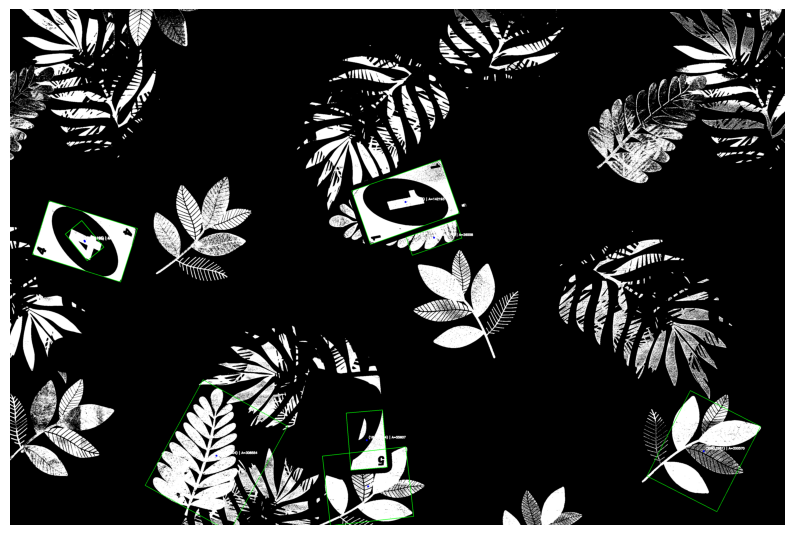

In [14]:
plot_bounding_boxes(mask=final_mask,bounding_boxes=bounding_boxes)

In [ ]:
#to do :
#remove contours stricly inside of others 
#detect highest aspect ratio as player (take area into account)
#find a way to remove the fucking leaves (could be that there is no number??)
#optimize thresholds and shit
